# Lab 3 – Image Manipulations using OpenCV Library

**Student Name:** Danyal Salman Alhashem

**Student ID:** 2240002713


**Outcomes:** Explain how digital images are represented and manipulated in a computer, and apply geometric and intensity transformations to images.

## Setup
`cv2.imshow()` opens a separate desktop window, which does not render inside a Jupyter notebook.
The helper `show()` below displays images inline with Matplotlib (converting OpenCV's **BGR** order to **RGB**).
The original `cv2.imshow()` / `cv2.waitKey()` calls from the manual are kept as comments so they can be run from a normal Python script.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('images', exist_ok=True)
print('OpenCV version:', cv2.__version__)

def show(images, titles, cols=None, size=4.5):
    """Display one or more images inline (BGR colour or grayscale)."""
    if not isinstance(images, (list, tuple)):
        images, titles = [images], [titles]
    cols = cols or len(images)
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=(size * cols, size * rows))
    for i, (im, t) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i + 1)
        if im.ndim == 2:
            plt.imshow(im, cmap='gray', vmin=0, vmax=255)
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.title(f'{t}\n{im.shape[1]}x{im.shape[0]}', fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

OpenCV version: 5.0.0


---
# Part A – Procedural Steps

## Step 1: Read an image using OpenCV
The image used in this lab is `images/input.jpg`.

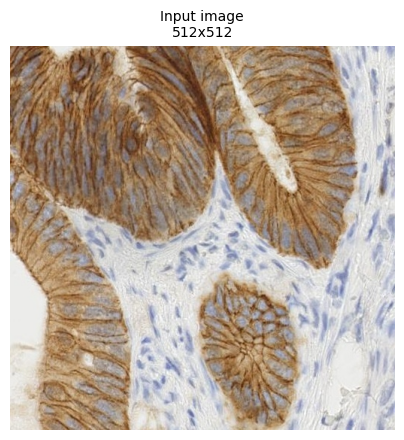

type(img)  : <class 'numpy.ndarray'>
dtype      : uint8
shape      : (512, 512, 3) -> (height, width, channels)
pixel [0,0]: [ 82 119 157] (B, G, R)


In [2]:
img = cv2.imread('./images/input.jpg')
# cv2.imshow('Input image', img); cv2.waitKey()   # desktop-window version
show(img, 'Input image')

print('type(img)  :', type(img))
print('dtype      :', img.dtype)
print('shape      :', img.shape, '-> (height, width, channels)')
print('pixel [0,0]:', img[0, 0], '(B, G, R)')

An image is read as a **NumPy `ndarray`** of `uint8` values (0–255) with shape `(rows, cols, 3)`.
OpenCV stores the three colour channels in **B, G, R** order.

## Step 2: Load an image in grayscale mode

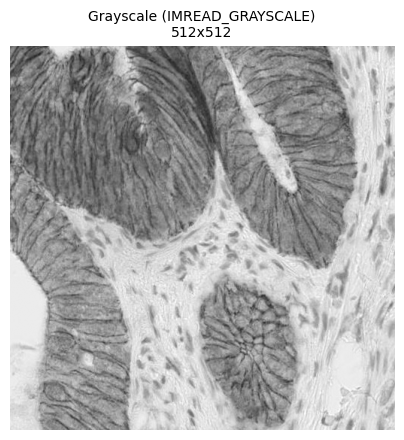

shape: (512, 512) -> a single channel


In [3]:
gray_img = cv2.imread('images/input.jpg', cv2.IMREAD_GRAYSCALE)
# cv2.imshow('Grayscale', gray_img); cv2.waitKey()
show(gray_img, 'Grayscale (IMREAD_GRAYSCALE)')
print('shape:', gray_img.shape, '-> a single channel')

## Step 3: Save an image

In [4]:
ok = cv2.imwrite('images/output.jpg', gray_img)
print('Saved images/output.jpg:', ok)

Saved images/output.jpg: True


## Step 4: Convert an image to different colour spaces

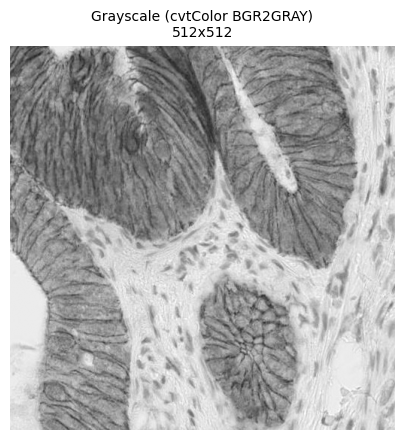

In [5]:
img = cv2.imread('./images/input.jpg')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# cv2.imshow('Grayscale image', gray_img); cv2.waitKey()
show(gray_img, 'Grayscale (cvtColor BGR2GRAY)')

In [6]:
# All colour-conversion flags available in OpenCV
# (the manual uses Python 2 syntax: print [..]; in Python 3 print needs parentheses)
flags = [x for x in dir(cv2) if x.startswith('COLOR_')]
print('Number of COLOR_ flags:', len(flags))
print(flags[:20], '...')

Number of COLOR_ flags: 374
['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA'] ...


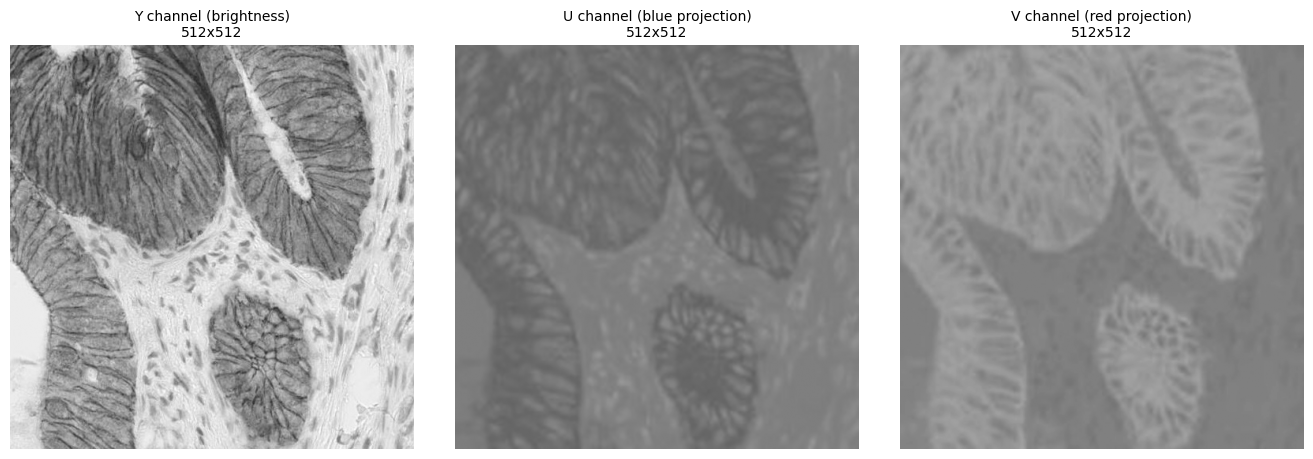

In [7]:
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
# cv2.imshow('Y channel', yuv_img[:, :, 0])
# cv2.imshow('U channel', yuv_img[:, :, 1])
# cv2.imshow('V channel', yuv_img[:, :, 2])
# cv2.waitKey()
show([yuv_img[:, :, 0], yuv_img[:, :, 1], yuv_img[:, :, 2]],
     ['Y channel (brightness)', 'U channel (blue projection)', 'V channel (red projection)'])

**Y** carries the brightness (it looks like a grayscale image), while **U** and **V** carry colour information
(blue-difference and red-difference), so they look flat grey except in strongly coloured regions.

---
# Part B – Assessment

## Task 1: Geometric Transformations

### 1.1 Increase the size of the image
`cv2.resize()` with scale factor 2 in both directions. `INTER_CUBIC` interpolation is used because it gives
smoother results than nearest-neighbour or bilinear when **enlarging**.

Original size : 512 x 512
Enlarged size : 1024 x 1024


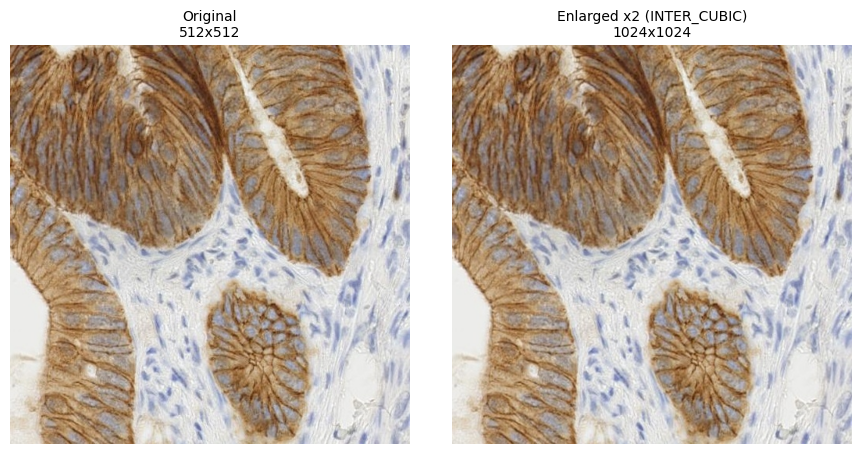

In [8]:
scale = 2.0
enlarged = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
cv2.imwrite('images/task1_1_enlarged.jpg', enlarged)

print('Original size :', img.shape[1], 'x', img.shape[0])
print('Enlarged size :', enlarged.shape[1], 'x', enlarged.shape[0])
show([img, enlarged], ['Original', 'Enlarged x2 (INTER_CUBIC)'])

### 1.2 Rotate the image by 120 degrees
`cv2.getRotationMatrix2D(center, angle, scale)` builds the 2×3 affine matrix

$$M = \begin{bmatrix} \alpha & \beta & (1-\alpha)c_x - \beta c_y \\ -\beta & \alpha & \beta c_x + (1-\alpha) c_y \end{bmatrix},\quad \alpha=\cos\theta,\ \beta=\sin\theta$$

A positive angle rotates **counter-clockwise**. To avoid cutting off the corners, the output canvas is enlarged to
the rotated image's bounding box and the translation part of `M` is shifted to the new centre.

Rotation matrix (120 deg):
 [[ -0.5     0.866 255.797]
 [ -0.866  -0.5   699.203]]


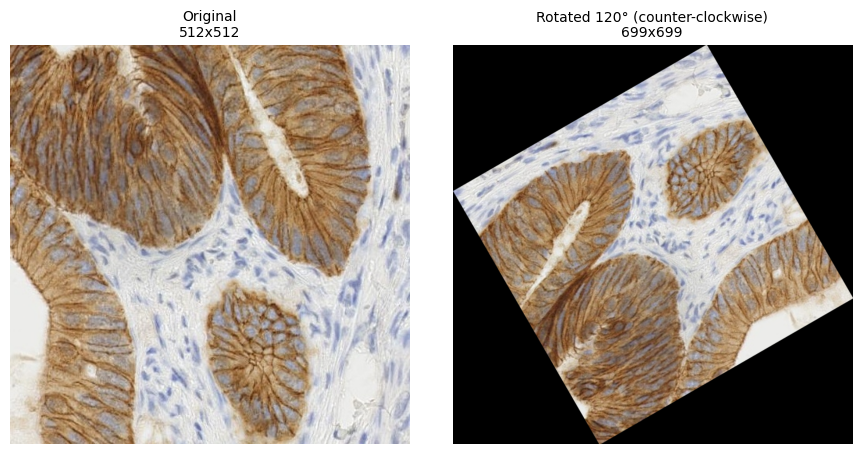

In [9]:
def rotate_bound(image, angle):
    h, w = image.shape[:2]
    cx, cy = w / 2, h / 2
    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)
    M[0, 2] += new_w / 2 - cx
    M[1, 2] += new_h / 2 - cy
    return cv2.warpAffine(image, M, (new_w, new_h)), M

rotated, M_rot = rotate_bound(img, 120)
cv2.imwrite('images/task1_2_rotated_120.jpg', rotated)

np.set_printoptions(suppress=True)
print('Rotation matrix (120 deg):\n', np.round(M_rot, 3))
show([img, rotated], ['Original', 'Rotated 120° (counter-clockwise)'])

### 1.3 Shear operations
Shearing slants the image along one axis:

* Horizontal shear: $x' = x + sh_x\,y,\ y' = y$  → $M = \begin{bmatrix}1 & sh_x & 0\\0 & 1 & 0\end{bmatrix}$
* Vertical shear: $x' = x,\ y' = y + sh_y\,x$  → $M = \begin{bmatrix}1 & 0 & 0\\sh_y & 1 & 0\end{bmatrix}$

The output size is increased so the whole sheared image stays visible.

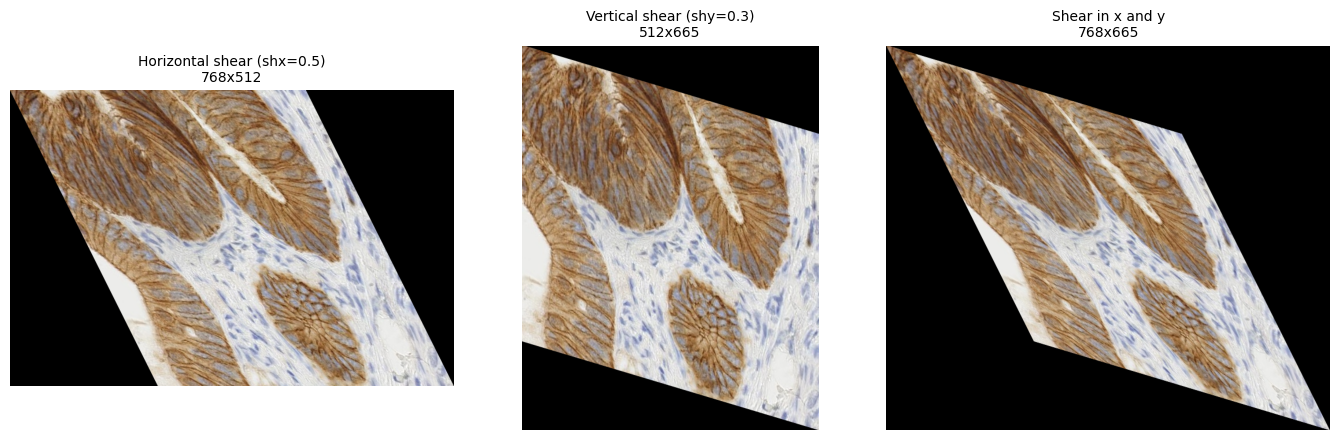

In [10]:
h, w = img.shape[:2]
shx, shy = 0.5, 0.3

# Horizontal shear (along x)
M_shx = np.float32([[1, shx, 0],
                    [0, 1,   0]])
sheared_x = cv2.warpAffine(img, M_shx, (int(w + shx * h), h))

# Vertical shear (along y)
M_shy = np.float32([[1,   0, 0],
                    [shy, 1, 0]])
sheared_y = cv2.warpAffine(img, M_shy, (w, int(h + shy * w)))

# Shear in both directions
M_shxy = np.float32([[1,   shx, 0],
                     [shy, 1,   0]])
sheared_xy = cv2.warpAffine(img, M_shxy, (int(w + shx * h), int(h + shy * w)))

cv2.imwrite('images/task1_3_shear_x.jpg', sheared_x)
cv2.imwrite('images/task1_3_shear_y.jpg', sheared_y)
cv2.imwrite('images/task1_3_shear_xy.jpg', sheared_xy)

show([sheared_x, sheared_y, sheared_xy],
     [f'Horizontal shear (shx={shx})', f'Vertical shear (shy={shy})', 'Shear in x and y'])

## Task 2: Intensity Transformations
Intensity transformations are applied point-by-point, $s = T(r)$, where $r$ is the input grey level and $s$ the output level.
The grayscale version of the image is used; $L = 256$ grey levels.

In [11]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print('Gray range: min =', gray.min(), ', max =', gray.max(), ', mean = %.1f' % gray.mean())

Gray range: min = 33 , max = 255 , mean = 163.2


### 2.1 Negative image
$$s = (L - 1) - r = 255 - r$$
Dark areas become bright and vice versa. It is useful for enhancing white or grey detail embedded in dark regions.

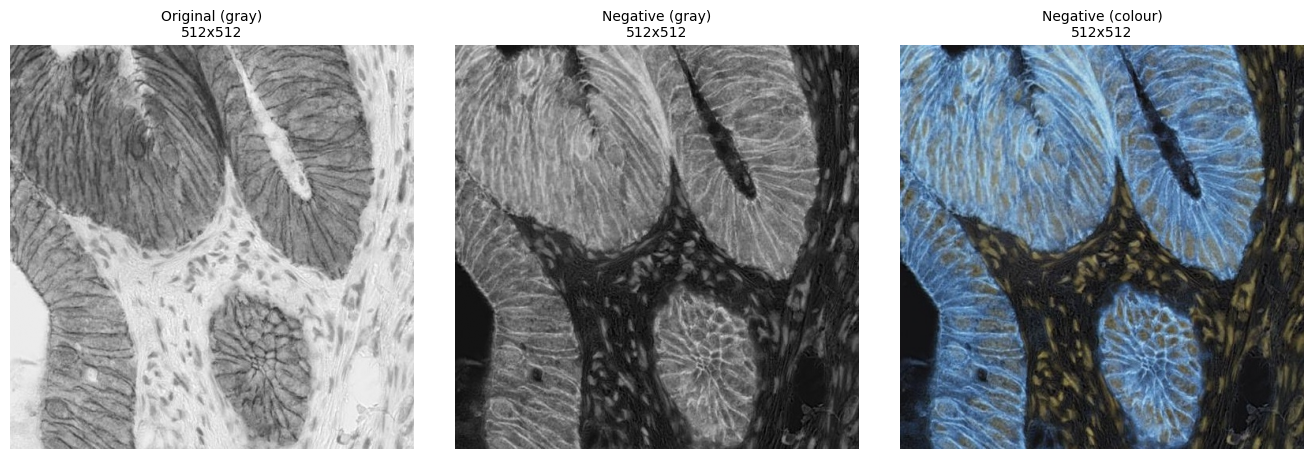

In [12]:
negative = 255 - gray              # equivalently cv2.bitwise_not(gray)
negative_color = 255 - img          # negative of the colour image as well
cv2.imwrite('images/task2_1_negative.jpg', negative)
cv2.imwrite('images/task2_1_negative_color.jpg', negative_color)

show([gray, negative, negative_color], ['Original (gray)', 'Negative (gray)', 'Negative (colour)'])

### 2.2 Log transformation
$$s = c \cdot \log(1 + r)$$
**Choice of constant $c$:** to use the full output range, $c$ is chosen so that the maximum input maps to 255:
$$c = \frac{255}{\log(1 + r_{max})}$$
The log curve expands dark values and compresses bright values, revealing detail in the shadows.

r_max = 255 ->  c = 255 / log(1 + r_max) = 45.986


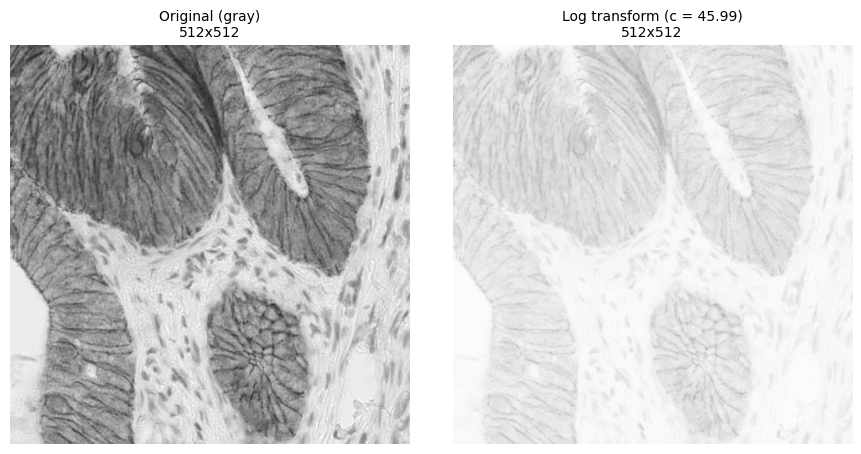

Mean intensity: before = 163.2, after = 232.0


In [13]:
r_max = int(gray.max())          # cast to int: 1 + 255 would overflow in uint8
c = 255 / np.log(1 + r_max)
print('r_max =', r_max, '->  c = 255 / log(1 + r_max) = %.3f' % c)

log_img = c * np.log(1 + gray.astype(np.float64))
log_img = np.clip(log_img, 0, 255).astype(np.uint8)
cv2.imwrite('images/task2_2_log.jpg', log_img)

show([gray, log_img], ['Original (gray)', f'Log transform (c = {c:.2f})'])
print('Mean intensity: before = %.1f, after = %.1f' % (gray.mean(), log_img.mean()))

### 2.3 Power-law (gamma) transformation
$$s = c \cdot r^{\gamma}\quad (r \text{ normalised to } [0,1],\ c = 255)$$
* $\gamma < 1$ brightens the image (expands dark values).
* $\gamma > 1$ darkens mid-tones and **stretches the bright range**, increasing contrast in a washed-out / bright image.

The test image (a bright stained-tissue micrograph, mean ≈ 160) is fairly bright and washed out, so **$\gamma = 2.0$** was chosen to increase contrast. $\gamma = 0.5$ and $\gamma = 1.5$ are shown for comparison.
Contrast is measured using the standard deviation of the intensities.

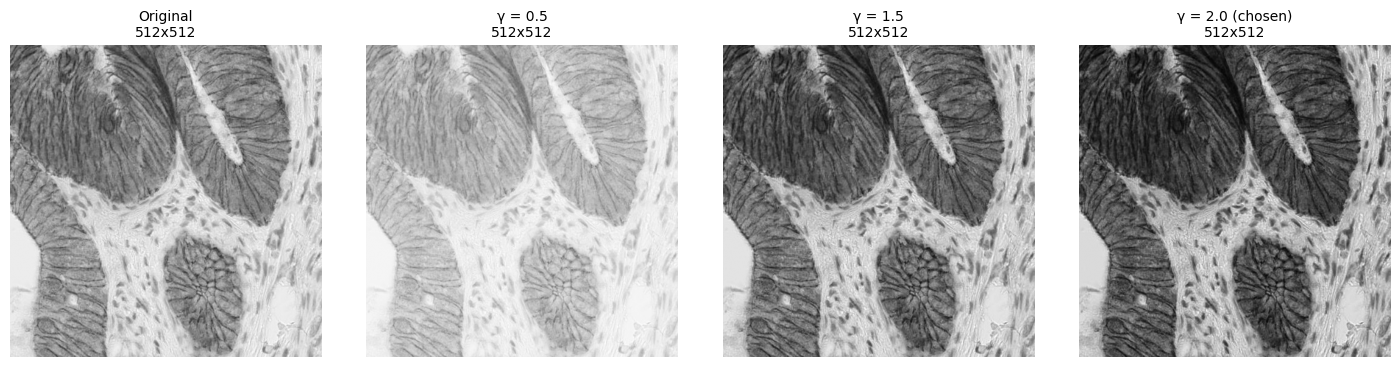

original  : mean =  163.2, contrast (std) =  47.3
gamma 0.5 : mean =  201.2, contrast (std) =  30.4
gamma 1.5 : mean =  134.3, contrast (std) =  56.5
gamma 2.0 : mean =  112.8, contrast (std) =  61.0


In [14]:
def gamma_correction(image, gamma):
    table = np.array([255 * (i / 255.0) ** gamma for i in range(256)]).astype(np.uint8)
    return cv2.LUT(image, table)     # fast look-up table

gamma = 2.0
power_img = gamma_correction(gray, gamma)
cv2.imwrite('images/task2_3_power_gamma2.jpg', power_img)

g05 = gamma_correction(gray, 0.5)
g15 = gamma_correction(gray, 1.5)

show([gray, g05, g15, power_img],
     ['Original', 'γ = 0.5', 'γ = 1.5', f'γ = {gamma} (chosen)'], cols=4, size=3.6)

for name, im in [('original', gray), ('gamma 0.5', g05), ('gamma 1.5', g15), ('gamma 2.0', power_img)]:
    print(f'{name:10s}: mean = {im.mean():6.1f}, contrast (std) = {im.std():5.1f}')

### Transformation curves and histograms

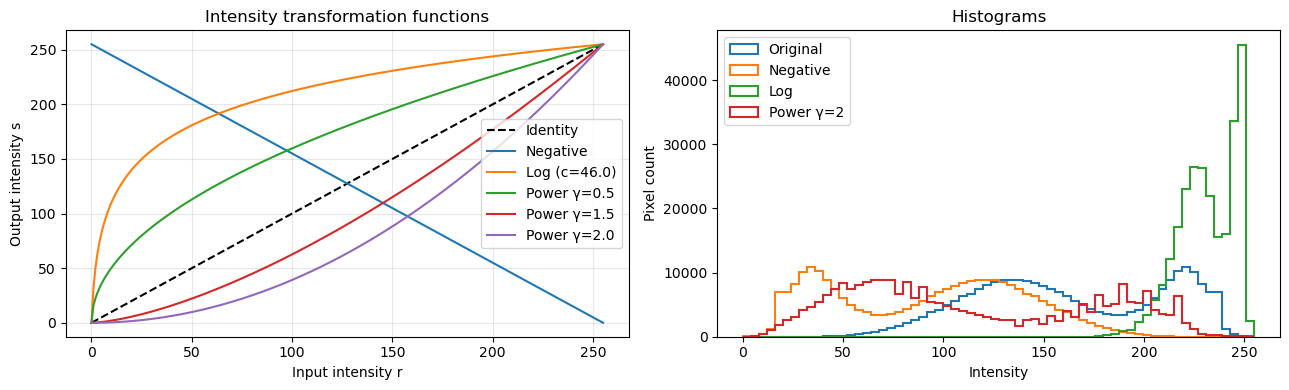

In [15]:
r = np.arange(256)
plt.figure(figsize=(13, 4))
plt.subplot(1, 2, 1)
plt.plot(r, r, 'k--', label='Identity')
plt.plot(r, 255 - r, label='Negative')
plt.plot(r, c * np.log(1 + r), label=f'Log (c={c:.1f})')
for g in [0.5, 1.5, 2.0]:
    plt.plot(r, 255 * (r / 255) ** g, label=f'Power γ={g}')
plt.xlabel('Input intensity r'); plt.ylabel('Output intensity s')
plt.title('Intensity transformation functions'); plt.legend(); plt.grid(alpha=.3)

plt.subplot(1, 2, 2)
for name, im in [('Original', gray), ('Negative', negative), ('Log', log_img), ('Power γ=2', power_img)]:
    plt.hist(im.ravel(), bins=64, range=(0, 255), histtype='step', linewidth=1.5, label=name)
plt.xlabel('Intensity'); plt.ylabel('Pixel count'); plt.title('Histograms'); plt.legend()
plt.tight_layout(); plt.savefig('images/curves_histograms.png', dpi=120); plt.show()

## Conclusion
* A digital image in OpenCV is a NumPy array of `uint8` values; colour images have 3 channels in **BGR** order and can be converted into many other colour spaces (374 COLOR_ flags in OpenCV 4.13) (Gray, YUV, HSV, …).
* **Geometric transformations** change *where* pixels are: resizing (interpolation), rotation (rotation matrix + translation), and shearing (affine matrix with an off-diagonal term), all done with `cv2.resize` / `cv2.warpAffine`.
* **Intensity transformations** change pixel *values*: the negative inverts intensities, the log transform brightens dark regions (with $c = 255/\log(1+r_{max})$), and the power-law with $\gamma = 2$ increased the contrast of this bright image, as shown by the higher standard deviation.